# Быстрый старт

Ниже приведен ряд максимально быстрого и простого использования библиотеки genesis.

:::{.callout-note}
## Прим.

Целевыми объектами являются *узлы графа* улично-дорожной сети. Примеры расчета для *зданий* рассмотрены в основных разделах документации.

:::

## Расчет оптимальной дислокации одной ПСЧ (BLP)

Расчет осуществляется с использованием **алгоритма обезьяньего поиска (MSA)**. Целевой функцией является **среднее время прибытия** пожарного подразделения в любую точку графа улично-дорожной сети. Используется стандартный **скоростной режим** (`DEFAULT_SPEEDS = [49, 37, 26, 16, 5]` км/ч).

Наиболее выгодная точка размещения: 1577701962
Среднее время следования в любую точку города: 4.110610741363095 мин


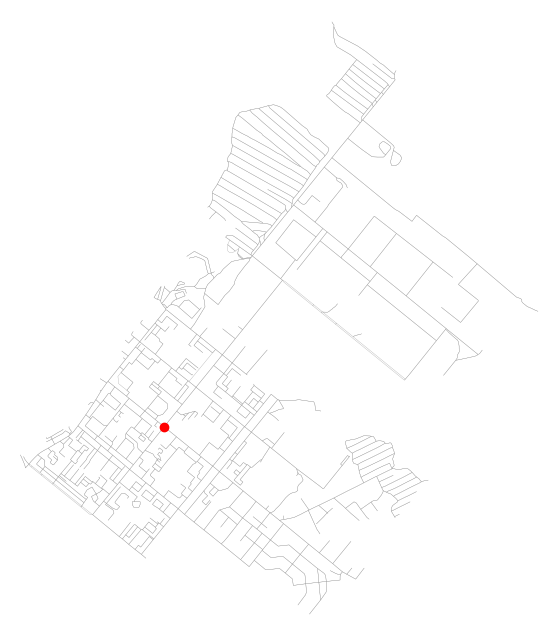

In [1]:
import osmnx as ox

from genesis.best_points import BestNodeMonkey
from genesis.metrics import ArrivalTime
from genesis.states import FirstArrivalUnitState
from graphs.speeds import kmh_to_mm, set_graph_travel_times
from fire_units.settings import DEFAULT_SPEEDS

# Загрузка ГДС
G = ox.graph_from_place(
    query        = 'Сосновоборск, Красноярский край, Россия',
    simplify     = False,
    network_type = 'drive_service')

# Установка скоростного режима
set_graph_travel_times(G, DEFAULT_SPEEDS, kmh_to_mm)

# Упрощаем граф для ускорения расчета
G = ox.simplify_graph(G)

# Использование алгоритма Обезьяньего поиска
blp = BestNodeMonkey(
    state_function  = FirstArrivalUnitState(),
    metric_function = ArrivalTime(),
    )

# Расчет лучшего размещения
best_node, best_metric = blp(G)

# Печать результата
print('Наиболее выгодная точка размещения:', best_node)
print('Среднее время следования в любую точку города:', best_metric, 'мин')

# Визуализация ГДС с оптимальной точкой размещения
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
ox.graph_to_gdfs(G, edges=False).loc[[best_node]].plot(ax=ax, color='red');

Визуализация поверх карты местности 🗺

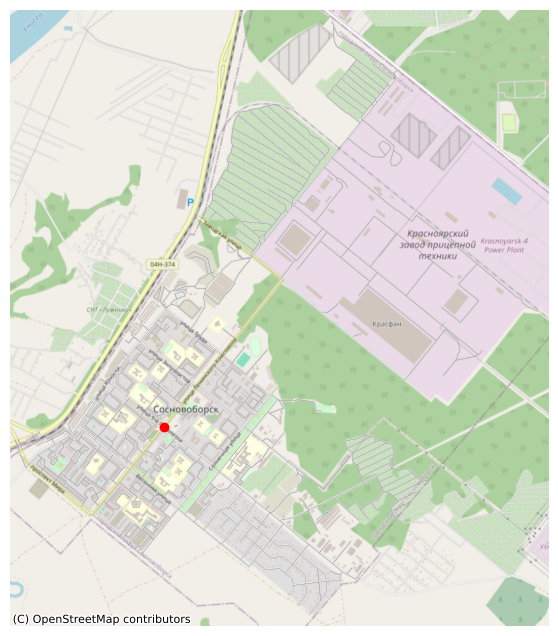

In [16]:
import contextily as ctx


fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
ox.graph_to_gdfs(G, edges=False).loc[[best_node]].plot(ax=ax, color='red')
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=G.graph['crs']);

## Расчет оптимальной дислокации 2 ПСЧ (MCLP)

### Без учета существующих ПСЧ


Наиболее выгодные точки размещения:
osmid
1577701962    POINT (93.33572 56.12016)
2034401362    POINT (93.35268 56.13656)
Name: geometry, dtype: geometry
Среднее время следования в любую точку города: 3.405565075116444 мин


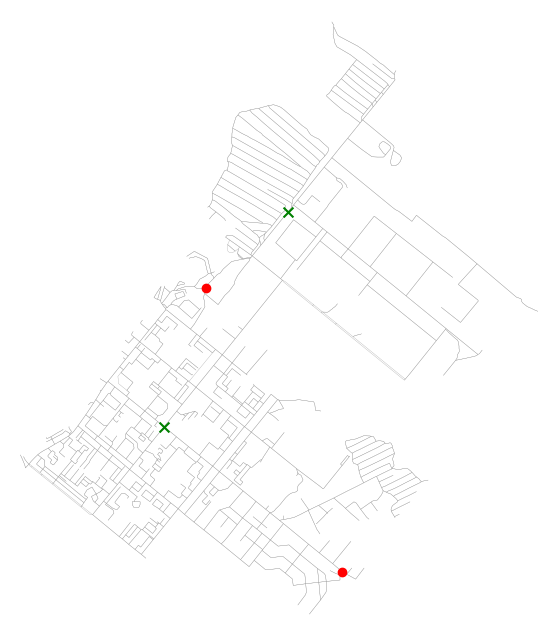

In [ ]:
import osmnx as ox

from genesis.metrics import ArrivalTime
from genesis.states import FirstArrivalUnitState
from graphs.speeds import kmh_to_mm, set_graph_travel_times
from fire_units.settings import DEFAULT_SPEEDS
from genesis.mclp import BestNodesGA
from genesis.point_selectors import RandomNodesSelector

# Загрузка ГДС
G = ox.graph_from_place(
    query        = 'Сосновоборск, Красноярский край, Россия',
    simplify     = False,
    network_type = 'drive_service')

# Установка скоростного режима
set_graph_travel_times(G, DEFAULT_SPEEDS, kmh_to_mm)

# Упрощаем граф для ускорения расчета
G = ox.simplify_graph(G)



# Создание стартового (произвольного) размещения ПСЧ
nodes = list(G.nodes())
start_nodes = {
    nodes[10]: 'псч 1',
    nodes[20]: 'псч 2',
}

# Использование Генетического алгоритма
mclp = BestNodesGA(
    state_function     = FirstArrivalUnitState(),
    metric_function    = ArrivalTime(),
    node_selector      = RandomNodesSelector(),
    mutation_max_count = 2,
    population_size    = 50,
    elite_size         = 15,
    epoch_end_function = lambda epoch, best_metric, **kwargs: print(epoch, best_metric, ' '*5, end='\r'),
)
print('')

# Расчет лучшего размещения
best_nodes, best_metric = mclp(
    env           = G,
    dynamic_nodes = start_nodes)



# Печать результата
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
print('Наиболее выгодные точки размещения:')
print(nodes_gdf.loc[best_nodes.keys()].geometry)
print('Среднее время следования в любую точку города:', best_metric, 'мин')

# Визуализация ГДС с оптимальной точкой размещения
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
nodes_gdf.loc[start_nodes.keys()].plot(ax=ax, color='r')
nodes_gdf.loc[best_nodes.keys()].plot(ax=ax, color='g', marker='x', markersize=50);

### С учетом существующих ПСЧ

Использован подход тот же что выше, но добавлено произвольное размещение имеющихся ПСЧ.


Наиболее выгодные точки размещения:
osmid
426923846     POINT (93.33099 56.1169)
426923850    POINT (93.34331 56.11672)
Name: geometry, dtype: geometry
Среднее время следования в любую точку города: 3.088321685207403 мин


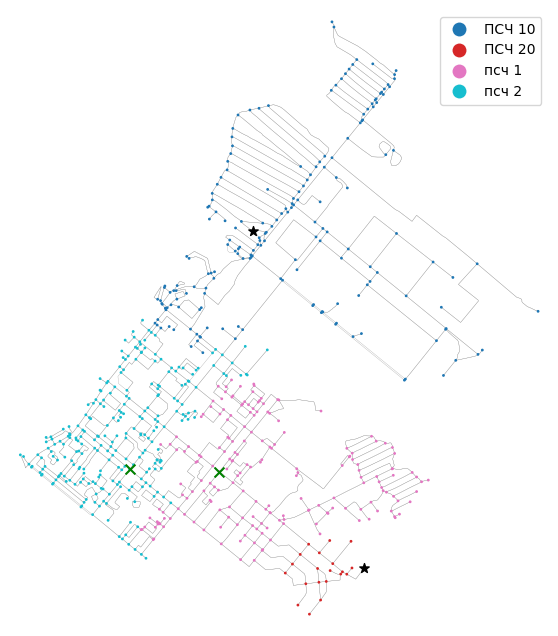

In [ ]:
import osmnx as ox
import pandas as pd

from genesis.metrics import ArrivalTime
from genesis.states import FirstArrivalUnitState
from graphs.speeds import kmh_to_mm, set_graph_travel_times
from fire_units.settings import DEFAULT_SPEEDS
from genesis.mclp import BestNodesGA
from genesis.point_selectors import RandomNodesSelector

# Подготовка исходных данных
## Загрузка ГДС
G = ox.graph_from_place(
    query        = 'Сосновоборск, Красноярский край, Россия',
    simplify     = False,
    network_type = 'drive_service')

## Установка скоростного режима
set_graph_travel_times(G, DEFAULT_SPEEDS, kmh_to_mm)

## Упрощаем граф для ускорения расчета
G = ox.simplify_graph(G)

## Создание стартового (произвольного) размещения ПСЧ
nodes = list(G.nodes())
start_nodes = {
    nodes[10]: 'псч 1',
    nodes[20]: 'псч 2',
}
## Создание размещения существующих подразделений (условно)
existing_nodes = {
    nodes[200]: 'ПСЧ 10',
    nodes[400]: 'ПСЧ 20',
}

# Подготовка алгоритмов расчета
## Использование Генетического алгоритма
mclp = BestNodesGA(
    state_function     = FirstArrivalUnitState(),
    metric_function    = ArrivalTime(),
    node_selector      = RandomNodesSelector(),
    mutation_max_count = 2,
    population_size    = 50,
    elite_size         = 15,
    epoch_end_function = lambda epoch, best_metric, **kwargs: print(epoch, best_metric, ' '*5, end='\r'),
)
print('')

# Проведение расчета
## Расчет лучшего размещения
best_nodes, best_metric = mclp(
    env           = G,
    dynamic_nodes = start_nodes,
    static_nodes  = existing_nodes)

# Печать результата
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
print('Наиболее выгодные точки размещения:')
print(nodes_gdf.loc[best_nodes.keys()].geometry)
print('Среднее время следования в любую точку города:', best_metric, 'мин')

# Визуализация ГДС с оптимальной точкой размещения
## Расчет времени для существующих подразделений и точек размещения
times, nearest = FirstArrivalUnitState()(G, {**best_nodes, **existing_nodes})

## Объединение датафрейма вершин ГДС и ближайшего к ним подразделения
nodes_gdf = pd.merge(nodes_gdf, nearest, left_index=True, right_index=True)

## Печать карты
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
nodes_gdf.plot(ax=ax, column='nearest', legend=True, markersize=1)
nodes_gdf.loc[existing_nodes.keys()].plot(ax=ax, color='k', marker='*', markersize=50)
nodes_gdf.loc[best_nodes.keys()].plot(ax=ax, color='g', marker='x', markersize=50);

:::{.callout-important}
## Важно

Генетический алгоритм (GA) в чистом виде не подходит для решения задачи размещения одной ПСЧ, т.к. в таком случае он вырождается в случайный поиск, что влечет неоправданное увеличение временных затрат и не гарантирует нахождение точного решения.

Для такой постановки задачи лучше использовать другие алгоритмы MCLP:

- Имитация отжига (SAA): `genesis.mclp.BestNodesSA`
- Генезис: `genesis.mclp.BestNodesKoptG`
- Жадное добавление (ADD): `genesis.lscp.LSCP_ADD`
- Гибрид GA+Генезис: `fire_units.mclp.BestNodesGAKopt`

Более подробно, см. в соответствующих разделах руководства.

:::

## Расчет оптимальной дислокации и требуемого количества ПСЧ (LSCP)

Используется алгоритм жадного добавления (ADD), соответствующий Методике определения числа и мест дислокации подразделений пожарной охраны изложенной в п. 4 [@SP_11].


:::{.callout-note}
## Прим.

В данном случае для наглядности, с учетом небольшого ГДС, взят **ИП-5** (индекс прикрытия для 5-ти минутной зоны).

При проведении реальных расчетов следует использовать **ИП-10** или **ИП-20** для расчета в соответствии со статьей 76 [@FZ123], или матрицу прибытия полученную с учетом максимально допустимых расстояний от объекта предполагаемого пожара  до ближайшего пожарного депо в соответствии с п. 5 [@SP_11].

:::

|########################################| 100.0%
Наиболее выгодные точки размещения:
osmid
1550088187     POINT (93.3382 56.12186)
2586140453    POINT (93.35024 56.11359)
2034401236     POINT (93.3744 56.12766)
2034401406    POINT (93.35346 56.13761)
2034401426      POINT (93.34232 56.138)
4116037089    POINT (93.37865 56.13262)
2034401612    POINT (93.36262 56.14339)
4116025706    POINT (93.36358 56.13101)
Name: geometry, dtype: geometry
ИП-5: 100.0 %
Среднее время следования в любую точку города: 2.8 мин
Максимальное время следования в любую точку города: 5.0 мин


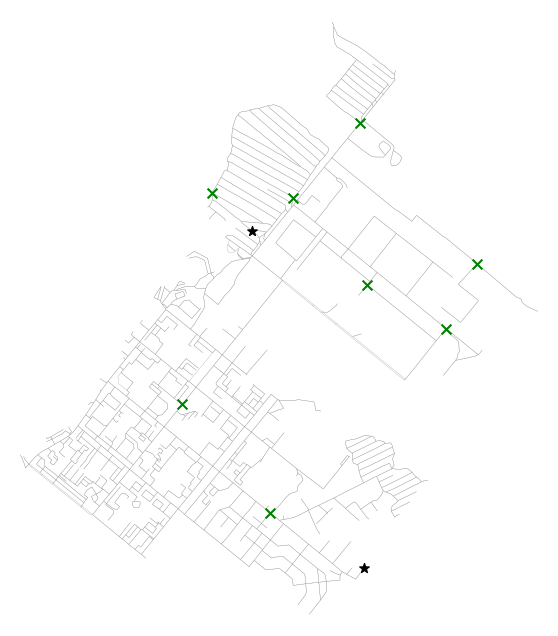

In [1]:
import osmnx as ox
import pandas as pd
import numpy as np

from genesis.metrics import ArrivalTime, CoverIndex
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState, ArrivalTimeMatrixState, get_atm
from graphs.speeds import kmh_to_mm, set_graph_travel_times
from fire_units.settings import DEFAULT_SPEEDS


# Подготовка исходных данных
## Загрузка ГДС
G = ox.graph_from_place(
    query        = 'Сосновоборск, Красноярский край, Россия',
    simplify     = False,
    network_type = 'drive_service')

## Установка скоростного режима
set_graph_travel_times(G, DEFAULT_SPEEDS, kmh_to_mm)

## Упрощаем граф для ускорения расчета
G = ox.simplify_graph(G)

## Создание размещения существующих подразделений (условно)
nodes = list(G.nodes())
existing_nodes = {
    nodes[200]: 'ПСЧ 10',
    nodes[400]: 'ПСЧ 20',
}


# Подготовка алгоритмов расчета
## Расчет матрицы прибытия
g_nodes = ox.graph_to_gdfs(G, edges=False)
g_nodes['node'] = g_nodes.index
matrix = get_atm(G, g_nodes)

## Использование Алгоритма жадного добавления для ИП-5
add = LSCP_ADD(
    state_function      = ArrivalTimeMatrixState(matrix),
    matrix              = matrix,
    metric_function     = CoverIndex(5),
    ip_val              = 5,
    )


# Проведение расчета
## Расчет лучшего размещения
best_nodes, best_metric = add(
    env          = G,
    static_nodes = existing_nodes
)


# Печать результата
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
print('Наиболее выгодные точки размещения:')
print(nodes_gdf.loc[best_nodes.keys()].geometry)
print('ИП-5:', best_metric, '%')

## Расчет времени прибытия для существующих подразделений и полученных точек размещения
times, nearest = FirstArrivalUnitState()(G, {**best_nodes, **existing_nodes})
print('Среднее время следования в любую точку города:', round(ArrivalTime()(times),1), 'мин')
print('Максимальное время следования в любую точку города:', round(ArrivalTime(np.max)(times),1), 'мин')


# Визуализация ГДС с оптимальными точками размещения
## Печать карты
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
nodes_gdf.loc[existing_nodes.keys()].plot(ax=ax, color='k', marker='*', markersize=50)
nodes_gdf.loc[best_nodes.keys()].plot(ax=ax, color='g', marker='x', markersize=50);